# Aula 05 — Avaliação de Estratégias de Chunking com LangChain

Este notebook implementa o pipeline completo solicitado:

**PDF → Markdown estruturado → 10 estratégias de chunking → embeddings → JSON → estatísticas → análise comparativa → conclusão para RAG**

A implementação também registra como **tabelas e imagens** foram tratadas na conversão PDF → Markdown e preserva metadados de página e, quando disponíveis, headings/seções.

> **Observação:** a escolha final da melhor estratégia para RAG deve ser interpretada como uma conclusão experimental sobre os documentos processados. O notebook não afirma que uma estratégia é universalmente melhor sem um conjunto de perguntas/ground truth de recuperação.


In [1]:
# ============================================================
# 1. INSTALAÇÃO
# ============================================================
!pip -q install -U pymupdf langchain-core langchain-text-splitters langchain-huggingface sentence-transformers pandas numpy

# Opcional para contagem de tokens
!pip -q install tiktoken


In [2]:
# ============================================================
# 2. CONFIGURAÇÃO
# ============================================================
from pathlib import Path
import os
import re
import json
import math
import shutil
import statistics
from typing import List, Dict, Any, Tuple

import fitz  # PyMuPDF
import numpy as np
import pandas as pd

from langchain_core.documents import Document
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter,
    MarkdownHeaderTextSplitter,
)
from langchain_huggingface import HuggingFaceEmbeddings

# ------------------------------------------------------------
# Ajuste somente estes caminhos se necessário
# ------------------------------------------------------------
ZIP_PATH = Path("/content/drive-download-20260812T171922Z-1-001.zip")

EXTRACT_DIR = Path("/content/documents_extracted")
RESULTS_DIR = Path("/content/results")

# Modelo único para os 10 experimentos
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# Para não recalcular tudo se você executar novamente
REUSE_EXISTING_JSON = True

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuração carregada.")
print("ZIP:", ZIP_PATH)
print("Resultados:", RESULTS_DIR)
print("Embedding:", EMBEDDING_MODEL)


Configuração carregada.
ZIP: /content/drive-download-20260812T171922Z-1-001.zip
Resultados: /content/results
Embedding: sentence-transformers/all-MiniLM-L6-v2


In [3]:
# ============================================================
# 3. DESCOMPACTAÇÃO DOS PDFs
# ============================================================
import zipfile

if ZIP_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print(f"Arquivos extraídos em: {EXTRACT_DIR}")
else:
    print(f"ZIP não encontrado: {ZIP_PATH}")
    print("Se os PDFs já estiverem em EXTRACT_DIR, o processamento continuará.")

pdf_files = sorted(EXTRACT_DIR.rglob("*.pdf"))

print(f"\nTotal de PDFs encontrados: {len(pdf_files)}")
for p in pdf_files:
    print(" -", p.relative_to(EXTRACT_DIR))


Arquivos extraídos em: /content/documents_extracted

Total de PDFs encontrados: 12
 - attention_is_all_you_need.pdf
 - bert_pretraining.pdf
 - bioetica_e_ia.pdf
 - escrita_academica_ia.pdf
 - gpt3_language_models.pdf
 - gpt4_technical_report.pdf
 - instruct_gpt.pdf
 - llama_foundation_models.pdf
 - lora_low_rank_adaptation.pdf
 - retrieval_augmented_generation.pdf
 - scaling_laws_llm.pdf
 - twitter_algoritmo.pdf


## 4. PDF → Markdown

A extração abaixo tenta preservar:

- número da página;
- texto;
- tabelas, quando o PyMuPDF consegue identificá-las;
- imagens, salvando-as separadamente e criando referências no Markdown;
- ordem dos elementos por página.

A extração de headings de um PDF não é garantida porque muitos PDFs não armazenam semanticamente a informação de `H1/H2/H3`. Por isso, o notebook não inventa headings: ele registra páginas e, quando possível, usa blocos de texto destacados.


In [4]:
# ============================================================
# 5. FUNÇÕES DE EXTRAÇÃO PDF → MARKDOWN
# ============================================================

def clean_text(text: str) -> str:
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    # Remove excesso de espaços sem destruir quebras de linha
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def dataframe_to_markdown(df) -> str:
    # Evita dependência de pandas.to_markdown/tabulate
    df = df.fillna("")
    headers = [str(c) for c in df.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |"
    ]
    for _, row in df.iterrows():
        values = [str(v).replace("|", "\\|").replace("\n", " ") for v in row]
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)


def extract_tables(page) -> List[str]:
    tables_md = []

    try:
        finder = page.find_tables()
        tables = getattr(finder, "tables", [])
        for i, table in enumerate(tables, start=1):
            try:
                df = table.to_pandas()
                if not df.empty:
                    tables_md.append(
                        f"### Tabela {i}\n\n{dataframe_to_markdown(df)}"
                    )
            except Exception as e:
                tables_md.append(
                    f"### Tabela {i}\n\n"
                    f"> Tabela detectada, mas não foi possível convertê-la para Markdown: {e}"
                )
    except Exception:
        # Algumas versões do PyMuPDF não possuem find_tables()
        pass

    return tables_md


def extract_images(page, image_dir: Path, page_number: int) -> List[str]:
    image_refs = []
    image_dir.mkdir(parents=True, exist_ok=True)

    for image_index, img in enumerate(page.get_images(full=True), start=1):
        try:
            xref = img[0]
            pix = fitz.Pixmap(page.parent, xref)

            if pix.n - pix.alpha < 4:
                image_path = image_dir / f"page_{page_number:03d}_image_{image_index:02d}.png"
                pix.save(str(image_path))
                image_refs.append(
                    f"![Imagem página {page_number} #{image_index}]"
                    f"(images/{image_path.name})"
                )
            else:
                pix0 = fitz.Pixmap(fitz.csRGB, pix)
                image_path = image_dir / f"page_{page_number:03d}_image_{image_index:02d}.png"
                pix0.save(str(image_path))
                image_refs.append(
                    f"![Imagem página {page_number} #{image_index}]"
                    f"(images/{image_path.name})"
                )
        except Exception as e:
            image_refs.append(
                f"> Imagem detectada na página {page_number}, "
                f"mas não foi possível exportá-la: {e}"
            )

    return image_refs


def extract_pdf_to_markdown(pdf_path: Path, output_doc_dir: Path) -> Dict[str, Any]:
    output_doc_dir.mkdir(parents=True, exist_ok=True)
    image_dir = output_doc_dir / "images"
    md_path = output_doc_dir / f"{pdf_path.stem}.md"

    doc = fitz.open(str(pdf_path))

    markdown = [
        f"# {pdf_path.stem.replace('_', ' ').title()}",
        "",
        "> Documento convertido automaticamente de PDF para Markdown.",
        ""
    ]

    extraction_report = {
        "document_name": pdf_path.name,
        "pages": len(doc),
        "tables_detected": 0,
        "images_detected": 0,
        "pages_with_text": 0,
        "notes": []
    }

    for page_number, page in enumerate(doc, start=1):
        markdown.append(f"## Página {page_number}")
        markdown.append("")

        text = clean_text(page.get_text("text"))

        if text:
            extraction_report["pages_with_text"] += 1
            markdown.append(text)
            markdown.append("")
        else:
            markdown.append("> Nenhum texto extraído desta página.")
            markdown.append("")

        tables = extract_tables(page)
        if tables:
            extraction_report["tables_detected"] += len(tables)
            markdown.append("### Tabelas")
            markdown.append("")
            markdown.extend(tables)
            markdown.append("")

        image_refs = extract_images(page, image_dir, page_number)
        if image_refs:
            extraction_report["images_detected"] += len(image_refs)
            markdown.append("### Imagens")
            markdown.append("")
            markdown.extend(image_refs)
            markdown.append("")

        markdown.append("---")
        markdown.append("")

    md_path.write_text("\n".join(markdown), encoding="utf-8")

    report_path = output_doc_dir / "extraction_report.json"
    report_path.write_text(
        json.dumps(extraction_report, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

    doc.close()

    return {
        "markdown_path": md_path,
        "report_path": report_path,
        **extraction_report
    }


In [5]:
# ============================================================
# 6. EXECUTAR PDF → MARKDOWN
# ============================================================

document_registry = []

for pdf_path in pdf_files:
    doc_id = f"doc{len(document_registry)+1:02d}"
    doc_dir = RESULTS_DIR / doc_id / "markdown"

    info = extract_pdf_to_markdown(pdf_path, doc_dir)

    document_registry.append({
        "document_id": doc_id,
        "document_name": pdf_path.name,
        "pdf_path": str(pdf_path),
        "markdown_path": str(info["markdown_path"]),
        "extraction_report": str(info["report_path"]),
        "pages": info["pages"],
        "tables_detected": info["tables_detected"],
        "images_detected": info["images_detected"],
    })

registry_path = RESULTS_DIR / "documents_registry.json"
registry_path.write_text(
    json.dumps(document_registry, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

display(pd.DataFrame(document_registry))


Consider using the pymupdf_layout package for a greatly improved page layout analysis.


,document_id,document_name,pdf_path,markdown_path,extraction_report,pages,tables_detected,images_detected
0,doc01,attention_is_all_you_need.pdf,/content/documents_extracted/attention_is_all_...,/content/results/doc01/markdown/attention_is_a...,/content/results/doc01/markdown/extraction_rep...,15,6,3
1,doc02,bert_pretraining.pdf,/content/documents_extracted/bert_pretraining.pdf,/content/results/doc02/markdown/bert_pretraini...,/content/results/doc02/markdown/extraction_rep...,16,5,34
2,doc03,bioetica_e_ia.pdf,/content/documents_extracted/bioetica_e_ia.pdf,/content/results/doc03/markdown/bioetica_e_ia.md,/content/results/doc03/markdown/extraction_rep...,12,0,0
3,doc04,escrita_academica_ia.pdf,/content/documents_extracted/escrita_academica...,/content/results/doc04/markdown/escrita_academ...,/content/results/doc04/markdown/extraction_rep...,14,0,5
4,doc05,gpt3_language_models.pdf,/content/documents_extracted/gpt3_language_mod...,/content/results/doc05/markdown/gpt3_language_...,/content/results/doc05/markdown/extraction_rep...,75,0,83
5,doc06,gpt4_technical_report.pdf,/content/documents_extracted/gpt4_technical_re...,/content/results/doc06/markdown/gpt4_technical...,/content/results/doc06/markdown/extraction_rep...,100,13,10
6,doc07,instruct_gpt.pdf,/content/documents_extracted/instruct_gpt.pdf,/content/results/doc07/markdown/instruct_gpt.md,/content/results/doc07/markdown/extraction_rep...,68,9,7
7,doc08,llama_foundation_models.pdf,/content/documents_extracted/llama_foundation_...,/content/results/doc08/markdown/llama_foundati...,/content/results/doc08/markdown/extraction_rep...,27,4,0
8,doc09,lora_low_rank_adaptation.pdf,/content/documents_extracted/lora_low_rank_ada...,/content/results/doc09/markdown/lora_low_rank_...,/content/results/doc09/markdown/extraction_rep...,26,2,27
9,doc10,retrieval_augmented_generation.pdf,/content/documents_extracted/retrieval_augment...,/content/results/doc10/markdown/retrieval_augm...,/content/results/doc10/markdown/extraction_rep...,19,3,2


## 7. As 10 estratégias

Os testes seguem o enunciado:

1. 200 caracteres, sem overlap
2. 500 caracteres, sem overlap
3. 1000 caracteres, sem overlap
4. 2000 caracteres, sem overlap
5. 500 caracteres, overlap 50
6. 500 caracteres, overlap 200
7. parágrafo
8. 3 sentenças por chunk
9. Recursive Character Text Splitter
10. Markdown por headings


In [6]:
# ============================================================
# 8. CONFIGURAÇÃO DOS 10 EXPERIMENTOS
# ============================================================

EXPERIMENTS = [
    {
        "test_id": 1,
        "strategy": "fixed_200_no_overlap",
        "type": "fixed",
        "chunk_size": 200,
        "chunk_overlap": 0,
    },
    {
        "test_id": 2,
        "strategy": "fixed_500_no_overlap",
        "type": "fixed",
        "chunk_size": 500,
        "chunk_overlap": 0,
    },
    {
        "test_id": 3,
        "strategy": "fixed_1000_no_overlap",
        "type": "fixed",
        "chunk_size": 1000,
        "chunk_overlap": 0,
    },
    {
        "test_id": 4,
        "strategy": "fixed_2000_no_overlap",
        "type": "fixed",
        "chunk_size": 2000,
        "chunk_overlap": 0,
    },
    {
        "test_id": 5,
        "strategy": "fixed_500_overlap_50",
        "type": "fixed",
        "chunk_size": 500,
        "chunk_overlap": 50,
    },
    {
        "test_id": 6,
        "strategy": "fixed_500_overlap_200",
        "type": "fixed",
        "chunk_size": 500,
        "chunk_overlap": 200,
    },
    {
        "test_id": 7,
        "strategy": "paragraph",
        "type": "paragraph",
        "chunk_size": None,
        "chunk_overlap": 0,
    },
    {
        "test_id": 8,
        "strategy": "sentences_3",
        "type": "sentences",
        "sentences_per_chunk": 3,
        "chunk_size": None,
        "chunk_overlap": 0,
    },
    {
        "test_id": 9,
        "strategy": "recursive",
        "type": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
    },
    {
        "test_id": 10,
        "strategy": "markdown_headers",
        "type": "markdown",
        "chunk_size": None,
        "chunk_overlap": 0,
    },
]

pd.DataFrame(EXPERIMENTS)


,test_id,strategy,type,chunk_size,chunk_overlap,sentences_per_chunk
0,1,fixed_200_no_overlap,fixed,200.0,0,NaN
1,2,fixed_500_no_overlap,fixed,500.0,0,NaN
2,3,fixed_1000_no_overlap,fixed,1000.0,0,NaN
3,4,fixed_2000_no_overlap,fixed,2000.0,0,NaN
4,5,fixed_500_overlap_50,fixed,500.0,50,NaN
5,6,fixed_500_overlap_200,fixed,500.0,200,NaN
6,7,paragraph,paragraph,NaN,0,NaN
7,8,sentences_3,sentences,NaN,0,3.0
8,9,recursive,recursive,1000.0,200,NaN
9,10,markdown_headers,markdown,NaN,0,NaN


In [7]:
# ============================================================
# 9. SEGMENTAÇÃO DE SENTENÇAS
# ============================================================

# Regex simples, mas muito mais segura que split("."):
# mantém ., ! e ? como terminadores e evita alguns casos comuns.
SENTENCE_PATTERN = re.compile(
    r"(?s).*?(?:[^.!?]|\b(?:Dr|Sr|Sra|Prof|etc|ex)\.)+[.!?](?=\s|$)|.+$"
)

def split_sentences(text: str) -> List[str]:
    text = clean_text(text)
    if not text:
        return []

    # Primeiro tenta uma segmentação por linhas/parágrafos.
    paragraphs = re.split(r"\n\s*\n", text)
    sentences = []

    for paragraph in paragraphs:
        paragraph = paragraph.strip()
        if not paragraph:
            continue

        # Proteção básica para abreviações frequentes
        protected = paragraph
        replacements = {
            "Dr.": "Dr<prd>",
            "Sr.": "Sr<prd>",
            "Sra.": "Sra<prd>",
            "Prof.": "Prof<prd>",
            "etc.": "etc<prd>",
            "ex.": "ex<prd>",
        }

        for old, new in replacements.items():
            protected = protected.replace(old, new)

        parts = re.split(r"(?<=[.!?])\s+", protected)

        for part in parts:
            part = part.strip()
            for old, new in replacements.items():
                part = part.replace(new, old)
            if part:
                sentences.append(part)

    return sentences


def sentence_chunks(text: str, n_sentences: int = 3) -> List[str]:
    sentences = split_sentences(text)
    return [
        " ".join(sentences[i:i+n_sentences]).strip()
        for i in range(0, len(sentences), n_sentences)
        if sentences[i:i+n_sentences]
    ]


In [8]:
# ============================================================
# 10. APLICAÇÃO DOS SPLITTERS
# ============================================================

def paragraph_splitter(doc: Document) -> List[Document]:
    # Cada parágrafo não vazio vira uma unidade de contexto.
    paragraphs = [
        p.strip()
        for p in re.split(r"\n\s*\n", doc.page_content)
        if p.strip()
    ]

    return [
        Document(
            page_content=p,
            metadata={
                **doc.metadata,
                "unit": "paragraph",
            }
        )
        for p in paragraphs
    ]


def sentence_splitter(doc: Document, n_sentences: int = 3) -> List[Document]:
    chunks = sentence_chunks(doc.page_content, n_sentences)

    return [
        Document(
            page_content=text,
            metadata={
                **doc.metadata,
                "unit": "sentences",
                "sentences_per_chunk": n_sentences,
            }
        )
        for text in chunks
    ]


def apply_splitter(doc: Document, exp: Dict[str, Any]) -> List[Document]:
    stype = exp["type"]

    if stype == "fixed":
        splitter = CharacterTextSplitter(
            separator="",
            chunk_size=exp["chunk_size"],
            chunk_overlap=exp["chunk_overlap"],
        )
        return splitter.split_documents([doc])

    if stype == "paragraph":
        return paragraph_splitter(doc)

    if stype == "sentences":
        return sentence_splitter(
            doc,
            n_sentences=exp["sentences_per_chunk"]
        )

    if stype == "recursive":
        splitter = RecursiveCharacterTextSplitter(
            separators=["\n\n", "\n", " ", ""],
            chunk_size=exp["chunk_size"],
            chunk_overlap=exp["chunk_overlap"],
        )
        return splitter.split_documents([doc])

    if stype == "markdown":
        headers_to_split_on = [
            ("#", "Header 1"),
            ("##", "Header 2"),
            ("###", "Header 3"),
            ("####", "Header 4"),
        ]

        splitter = MarkdownHeaderTextSplitter(
            headers_to_split_on=headers_to_split_on,
            strip_headers=False,
        )

        chunks = splitter.split_text(doc.page_content)

        # Metadata do MarkdownHeaderTextSplitter é preservado.
        return chunks

    raise ValueError(f"Tipo de experimento desconhecido: {stype}")


## 11. Métricas

Além da quantidade e do tamanho dos chunks, o notebook calcula:

- mínimo;
- máximo;
- média;
- mediana;
- desvio-padrão;
- tokens aproximados;
- dimensão dos embeddings;
- quantidade e percentual de overlap observado;
- quantidade de chunks com metadados estruturais;
- quantidade de chunks muito grandes;
- exemplos de chunks.

O overlap é estimado comparando o sufixo do chunk anterior com o prefixo do seguinte. Isso é útil para validar o efeito do parâmetro `chunk_overlap`.


In [9]:
# ============================================================
# 12. CONTAGEM DE TOKENS
# ============================================================

try:
    import tiktoken
    TOKEN_ENCODER = tiktoken.get_encoding("cl100k_base")

    def count_tokens(text: str) -> int:
        return len(TOKEN_ENCODER.encode(text))
except Exception:
    TOKEN_ENCODER = None

    def count_tokens(text: str) -> int:
        # Fallback transparente: aproximação simples
        return max(1, len(text.split()))


def longest_suffix_prefix_overlap(a: str, b: str, max_check: int = 1000) -> int:
    if not a or not b:
        return 0

    max_len = min(len(a), len(b), max_check)

    for n in range(max_len, 0, -1):
        if a[-n:] == b[:n]:
            return n

    return 0


def calculate_overlap_metrics(chunks: List[str]) -> Dict[str, Any]:
    if len(chunks) < 2:
        return {
            "overlap_pairs": 0,
            "overlap_chars_total": 0,
            "avg_observed_overlap_chars": 0,
            "overlap_percentage_pairs": 0.0,
        }

    overlaps = [
        longest_suffix_prefix_overlap(chunks[i], chunks[i+1])
        for i in range(len(chunks)-1)
    ]

    positive = [x for x in overlaps if x > 0]

    return {
        "overlap_pairs": len(positive),
        "overlap_chars_total": int(sum(overlaps)),
        "avg_observed_overlap_chars": round(
            float(np.mean(positive)) if positive else 0, 2
        ),
        "overlap_percentage_pairs": round(
            100 * len(positive) / len(overlaps), 2
        ),
    }


def calculate_statistics(chunks: List[Document]) -> Dict[str, Any]:
    texts = [c.page_content for c in chunks if c.page_content.strip()]
    sizes = [len(t) for t in texts]
    tokens = [count_tokens(t) for t in texts]

    overlap_metrics = calculate_overlap_metrics(texts)

    if not sizes:
        return {
            "num_chunks": 0,
            "avg_chunk_size": 0,
            "median_chunk_size": 0,
            "min_chunk_size": 0,
            "max_chunk_size": 0,
            "std_chunk_size": 0,
            "avg_tokens": 0,
            "min_tokens": 0,
            "max_tokens": 0,
            **overlap_metrics,
            "chunks_with_metadata": 0,
            "chunks_with_structural_metadata": 0,
            "chunks_over_2000_chars": 0,
        }

    structural_keys = {
        "Header 1", "Header 2", "Header 3", "Header 4",
        "section", "subsection", "heading", "heading_level"
    }

    structural_count = sum(
        bool(set(c.metadata.keys()) & structural_keys)
        for c in chunks
    )

    return {
        "num_chunks": len(texts),
        "avg_chunk_size": round(float(np.mean(sizes)), 2),
        "median_chunk_size": round(float(np.median(sizes)), 2),
        "min_chunk_size": int(min(sizes)),
        "max_chunk_size": int(max(sizes)),
        "std_chunk_size": round(float(np.std(sizes)), 2),
        "avg_tokens": round(float(np.mean(tokens)), 2),
        "min_tokens": int(min(tokens)),
        "max_tokens": int(max(tokens)),
        **overlap_metrics,
        "chunks_with_metadata": sum(bool(c.metadata) for c in chunks),
        "chunks_with_structural_metadata": int(structural_count),
        "chunks_over_2000_chars": int(sum(s > 2000 for s in sizes)),
    }


In [10]:
# ============================================================
#  13 -MODELO DE EMBEDDINGS -
# ============================================================
import os
from typing import List
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

# Carrega modelo
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)
model = AutoModel.from_pretrained(EMBEDDING_MODEL)
model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

class SafeTextEmbedder:
    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        if not texts:
            return []
        encoded_input = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
        with torch.no_grad():
            model_output = model(**encoded_input)
        sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
        sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
        return sentence_embeddings.tolist()

    def embed_query(self, text: str) -> List[float]:
        return self.embed_documents([text])[0]

# Instancia o embedder
embeddings_model = SafeTextEmbedder()

# Teste
test_embedding = embeddings_model.embed_query("teste")
EMBEDDING_DIMENSION = len(test_embedding)

print(" Modelo carregado com sucesso!")
print(f"Modelo: {EMBEDDING_MODEL}")
print(f"Dimensão: {EMBEDDING_DIMENSION}")
print(f"Primeiros 5 valores: {[round(x, 4) for x in test_embedding[:5]]}")
print(f"Norma: {sum(x**2 for x in test_embedding)**0.5:.4f}")

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 Modelo carregado com sucesso!
Modelo: sentence-transformers/all-MiniLM-L6-v2
Dimensão: 384
Primeiros 5 valores: [-0.0561, 0.0069, 0.0077, 0.0318, -0.0336]
Norma: 1.0000


In [11]:
# ============================================================
# 14. PROCESSAMENTO DE UM DOCUMENTO
# ============================================================

def process_document(
    md_path: Path,
    doc_id: str,
    doc_name: str,
    output_base: Path
) -> Dict[str, Any]:

    text_content = md_path.read_text(encoding="utf-8")

    base_doc = Document(
        page_content=text_content,
        metadata={
            "document_id": doc_id,
            "document_name": doc_name,
            "source": str(md_path),
        }
    )

    doc_output_dir = output_base / doc_id
    doc_output_dir.mkdir(parents=True, exist_ok=True)

    experiments_summary = []

    for exp in EXPERIMENTS:
        test_dir = doc_output_dir / f"test_{exp['test_id']:02d}"
        test_dir.mkdir(parents=True, exist_ok=True)

        output_file = test_dir / "chunks_embeddings.json"

        if REUSE_EXISTING_JSON and output_file.exists():
            records = json.loads(output_file.read_text(encoding="utf-8"))

            chunks = [
                Document(
                    page_content=r["text"],
                    metadata=r.get("metadata", {})
                )
                for r in records
            ]

            stats = calculate_statistics(chunks)
            embedding_dimension = (
                len(records[0]["embedding"]) if records else 0
            )

        else:
            chunks = apply_splitter(base_doc, exp)

            texts = [c.page_content for c in chunks]
            embeddings = (
                embeddings_model.embed_documents(texts)
                if texts else []
            )

            records = []

            for idx, (chunk, embedding) in enumerate(
                zip(chunks, embeddings), start=1
            ):
                record = {
                    "chunk_id": (
                        f"{doc_id}_test{exp['test_id']:02d}_chunk{idx:04d}"
                    ),
                    "document_id": doc_id,
                    "document_name": doc_name,
                    "test_id": exp["test_id"],
                    "strategy": exp["strategy"],
                    "chunk_size": exp.get("chunk_size"),
                    "chunk_overlap": exp.get("chunk_overlap", 0),
                    "text": chunk.page_content,
                    "embedding": embedding,
                    "metadata": chunk.metadata,
                }
                records.append(record)

            output_file.write_text(
                json.dumps(records, ensure_ascii=False, indent=2),
                encoding="utf-8"
            )

            stats = calculate_statistics(chunks)
            embedding_dimension = (
                len(records[0]["embedding"]) if records else 0
            )

        summary = {
            "test_id": exp["test_id"],
            "strategy": exp["strategy"],
            "configuration": {
                k: v for k, v in exp.items()
                if k not in {"test_id", "strategy", "type"}
            },
            **stats,
            "embedding_model": EMBEDDING_MODEL,
            "embedding_dimension": embedding_dimension,
            "example_chunks": [
                r["text"][:500] for r in records[:3]
            ],
        }

        experiments_summary.append(summary)

    doc_summary = {
        "document_id": doc_id,
        "document": doc_name,
        "embedding_model": EMBEDDING_MODEL,
        "embedding_dimension": EMBEDDING_DIMENSION,
        "experiments": experiments_summary,
    }

    summary_path = doc_output_dir / "summary.json"
    summary_path.write_text(
        json.dumps(doc_summary, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

    return doc_summary


In [12]:
# ============================================================
# 15. EXECUTAR OS 10 EXPERIMENTOS EM TODOS OS DOCUMENTOS
# ============================================================
import time
from datetime import datetime

print("=" * 60)
print(" INICIANDO PROCESSAMENTO DE DOCUMENTOS")
print("=" * 60)
print(f" Data/Hora: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Total de documentos: {len(document_registry)}")
print(f" Total de experimentos por documento: {len(EXPERIMENTS)}")
print(f" Modelo de embedding: {EMBEDDING_MODEL}")
print("=" * 60)

all_document_summaries = []
total_start_time = time.time()

for i, item in enumerate(document_registry, start=1):
    print(f"\n{'='*60}")
    print(f"[{i}/{len(document_registry)}]  PROCESSANDO: {item['document_name']}")
    print(f"{'='*60}")
    print(f" ID: {item['document_id']}")
    print(f" Path: {item['markdown_path']}")

    start_time = time.time()

    try:
        summary = process_document(
            md_path=Path(item["markdown_path"]),
            doc_id=item["document_id"],
            doc_name=item["document_name"],
            output_base=RESULTS_DIR,
        )

        elapsed = time.time() - start_time

        # Mostra estatísticas do documento
        print(f"\n {item['document_name']} - PROCESSADO COM SUCESSO!")
        print(f"     Tempo: {elapsed:.2f} segundos")
        print(f"    Experimentos: {len(summary['experiments'])}")

        # Mostra detalhes de cada experimento
        for exp in summary['experiments']:
            print(f"   └─ Teste {exp['test_id']:02d} ({exp['strategy']}): {exp.get('num_chunks', 0)} chunks, {exp.get('avg_chunk_size', 0):.0f} caracteres médios")

        all_document_summaries.append(summary)

    except Exception as e:
        print(f"\n ERRO ao processar {item['document_name']}:")
        print(f"   {type(e).__name__}: {str(e)}")
        # Continua com o próximo documento
        continue

# ============================================================
# SALVAR SUMMARY GLOBAL
# ============================================================
total_elapsed = time.time() - total_start_time

print("\n" + "="*60)
print(" FINALIZANDO PROCESSAMENTO")
print("="*60)

global_summary = {
    "project": "Avaliacao de Estrategias de Chunking com LangChain",
    "embedding_model": EMBEDDING_MODEL,
    "embedding_dimension": EMBEDDING_DIMENSION,
    "num_documents": len(all_document_summaries),
    "num_experiments": len(EXPERIMENTS),
    "documents": all_document_summaries,
    "processing_time_seconds": total_elapsed,
    "timestamp": datetime.now().isoformat(),
}

global_summary_path = RESULTS_DIR / "summary.json"
global_summary_path.write_text(
    json.dumps(global_summary, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# ============================================================
# RELATÓRIO FINAL
# ============================================================
print("\n" + "="*60)
print(" PROCESSAMENTO CONCLUÍDO!")
print("="*60)
print(f" Documentos processados: {len(all_document_summaries)}/{len(document_registry)}")
print(f" Experimentos por documento: {len(EXPERIMENTS)}")
print(f"  Tempo total: {total_elapsed:.2f} segundos")
print(f"  Tempo médio por documento: {total_elapsed/len(document_registry):.2f} segundos")

# Conta total de chunks
total_chunks = 0
for doc_summary in all_document_summaries:
    for exp in doc_summary['experiments']:
        total_chunks += exp.get('num_chunks', 0)

print(f" Total de chunks criados: {total_chunks}")
print(f" Summary salvo em: {global_summary_path}")
print(f" Pasta de resultados: {RESULTS_DIR}")

# Mostra os 3 primeiros documentos processados
print("\n PRIMEIROS DOCUMENTOS PROCESSADOS:")
for idx, doc_summary in enumerate(all_document_summaries[:3], 1):
    print(f"  {idx}. {doc_summary['document']}")
    for exp in doc_summary['experiments'][:2]:
        print(f"     └─ {exp['strategy']}: {exp.get('num_chunks', 0)} chunks")

if len(all_document_summaries) > 3:
    print(f"  ... e mais {len(all_document_summaries)-3} documentos")

print("\n" + "="*60)
print(" PRONTO PARA USAR OS DADOS!")
print("="*60)

 INICIANDO PROCESSAMENTO DE DOCUMENTOS
 Data/Hora: 2026-08-12 20:11:25
 Total de documentos: 12
 Total de experimentos por documento: 10
 Modelo de embedding: sentence-transformers/all-MiniLM-L6-v2

[1/12]  PROCESSANDO: attention_is_all_you_need.pdf
 ID: doc01
 Path: /content/results/doc01/markdown/attention_is_all_you_need.md

 attention_is_all_you_need.pdf - PROCESSADO COM SUCESSO!
     Tempo: 173.47 segundos
    Experimentos: 10
   └─ Teste 01 (fixed_200_no_overlap): 254 chunks, 199 caracteres médios
   └─ Teste 02 (fixed_500_no_overlap): 102 chunks, 497 caracteres médios
   └─ Teste 03 (fixed_1000_no_overlap): 51 chunks, 995 caracteres médios
   └─ Teste 04 (fixed_2000_no_overlap): 26 chunks, 1952 caracteres médios
   └─ Teste 05 (fixed_500_overlap_50): 113 chunks, 498 caracteres médios
   └─ Teste 06 (fixed_500_overlap_200): 169 chunks, 499 caracteres médios
   └─ Teste 07 (paragraph): 67 chunks, 756 caracteres médios
   └─ Teste 08 (sentences_3): 154 chunks, 319 caracteres médios

## 16. Tabela comparativa

Para comparar documentos diferentes, calculamos a média das métricas por estratégia.


In [13]:
# ============================================================
# 17. DATAFRAME GLOBAL DE RESULTADOS
# ============================================================

rows = []

for doc_summary in all_document_summaries:
    for exp in doc_summary["experiments"]:
        row = {
            "document_id": doc_summary["document_id"],
            "document": doc_summary["document"],
            **{
                k: v for k, v in exp.items()
                if k not in {"configuration", "example_chunks"}
            },
        }
        rows.append(row)

results_df = pd.DataFrame(rows)

display(results_df.head())


,document_id,document,test_id,strategy,num_chunks,avg_chunk_size,median_chunk_size,min_chunk_size,max_chunk_size,std_chunk_size,...,max_tokens,overlap_pairs,overlap_chars_total,avg_observed_overlap_chars,overlap_percentage_pairs,chunks_with_metadata,chunks_with_structural_metadata,chunks_over_2000_chars,embedding_model,embedding_dimension
0,doc01,attention_is_all_you_need.pdf,1,fixed_200_no_overlap,254,199.31,200.0,156,200,2.83,...,146,39,951,24.38,15.42,254,0,0,sentence-transformers/all-MiniLM-L6-v2,384
1,doc01,attention_is_all_you_need.pdf,2,fixed_500_no_overlap,102,497.12,500.0,256,500,24.00,...,320,17,374,22.00,16.83,102,0,0,sentence-transformers/all-MiniLM-L6-v2,384
2,doc01,attention_is_all_you_need.pdf,3,fixed_1000_no_overlap,51,994.75,1000.0,756,1000,33.77,...,561,8,139,17.38,16.00,51,0,0,sentence-transformers/all-MiniLM-L6-v2,384
3,doc01,attention_is_all_you_need.pdf,4,fixed_2000_no_overlap,26,1951.69,2000.0,756,2000,239.14,...,1024,3,3,1.00,12.00,26,0,0,sentence-transformers/all-MiniLM-L6-v2,384
4,doc01,attention_is_all_you_need.pdf,5,fixed_500_overlap_50,113,498.25,500.0,356,500,13.46,...,320,112,5792,51.71,100.00,113,0,0,sentence-transformers/all-MiniLM-L6-v2,384


In [14]:
# ============================================================
# 18. COMPARAÇÃO MÉDIA POR ESTRATÉGIA
# ============================================================

strategy_summary = (
    results_df
    .groupby(["test_id", "strategy"], as_index=False)
    .agg(
        num_chunks_mean=("num_chunks", "mean"),
        avg_chunk_size_mean=("avg_chunk_size", "mean"),
        min_chunk_size_mean=("min_chunk_size", "mean"),
        max_chunk_size_mean=("max_chunk_size", "mean"),
        avg_tokens_mean=("avg_tokens", "mean"),
        overlap_percentage_mean=("overlap_percentage_pairs", "mean"),
        structural_metadata_mean=("chunks_with_structural_metadata", "mean"),
        embedding_dimension=("embedding_dimension", "first"),
    )
    .sort_values("test_id")
)

display(strategy_summary)


,test_id,strategy,num_chunks_mean,avg_chunk_size_mean,min_chunk_size_mean,max_chunk_size_mean,avg_tokens_mean,overlap_percentage_mean,structural_metadata_mean,embedding_dimension
0,1,fixed_200_no_overlap,471.909091,199.390909,98.909091,200.000000,59.060909,4.230000,0.000000,384
1,2,fixed_500_no_overlap,189.181818,497.592727,189.636364,500.000000,146.119091,4.502727,0.000000,384
2,3,fixed_1000_no_overlap,94.909091,991.009091,371.636364,1000.000000,290.222727,4.127273,0.000000,384
3,4,fixed_2000_no_overlap,47.636364,1972.985455,1007.909091,2000.000000,576.849091,4.467273,0.000000,384
4,5,fixed_500_overlap_50,209.909091,498.232727,271.363636,500.000000,146.247273,100.000000,0.000000,384
5,6,fixed_500_overlap_200,314.090909,499.026364,353.363636,500.000000,146.630000,100.000000,0.000000,384
6,7,paragraph,113.818182,882.855455,3.000000,5041.272727,257.781818,1.086364,0.000000,384
7,8,sentences_3,347.909091,282.478182,11.000000,2453.363636,82.081818,6.911818,0.000000,384
8,9,recursive,150.181818,730.210000,16.090909,997.909091,212.218182,63.942727,0.000000,384
9,10,markdown_headers,42.636364,2328.486364,33.454545,5047.636364,677.548182,0.000000,42.636364,384


## 17. Visualizações

As visualizações não substituem a análise textual, mas ajudam a identificar rapidamente o comportamento das estratégias.


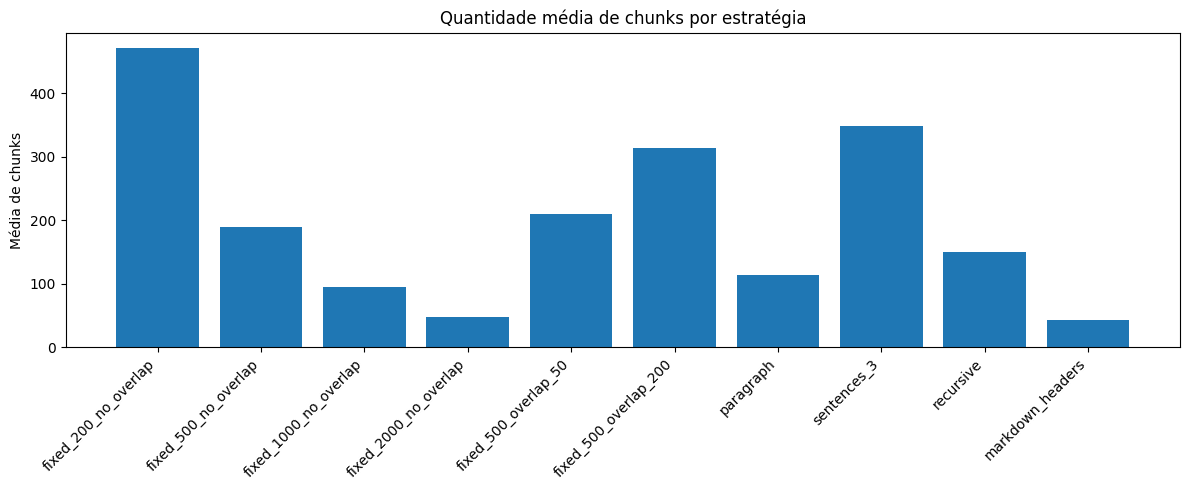

In [15]:
# ============================================================
# 19. GRÁFICO — QUANTIDADE DE CHUNKS
# ============================================================

import matplotlib.pyplot as plt

plot_df = strategy_summary.sort_values("test_id")

plt.figure(figsize=(12, 5))
plt.bar(
    plot_df["strategy"],
    plot_df["num_chunks_mean"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Média de chunks")
plt.title("Quantidade média de chunks por estratégia")
plt.tight_layout()
plt.show()


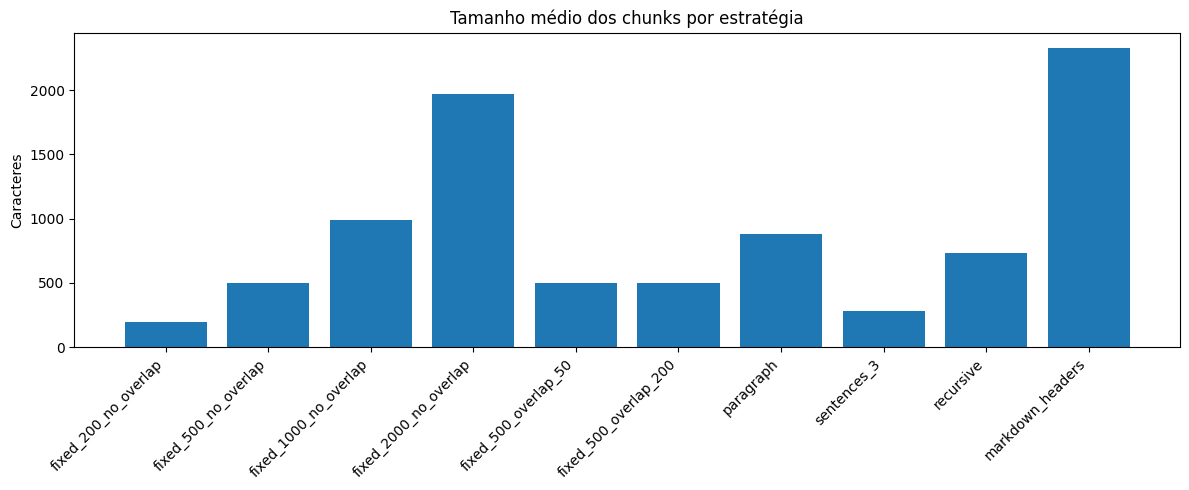

In [16]:
# ============================================================
# 20. GRÁFICO — TAMANHO MÉDIO
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(
    plot_df["strategy"],
    plot_df["avg_chunk_size_mean"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Caracteres")
plt.title("Tamanho médio dos chunks por estratégia")
plt.tight_layout()
plt.show()


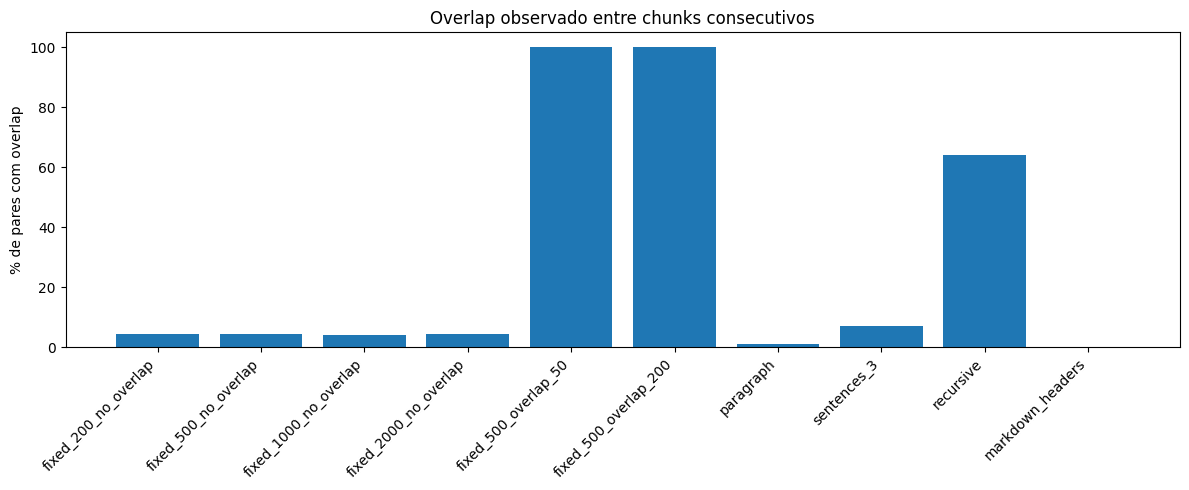

In [17]:
# ============================================================
# 21. GRÁFICO — OVERLAP OBSERVADO
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(
    plot_df["strategy"],
    plot_df["overlap_percentage_mean"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("% de pares com overlap")
plt.title("Overlap observado entre chunks consecutivos")
plt.tight_layout()
plt.show()


## 18. Análise automática das 15 perguntas

As respostas abaixo são **geradas a partir dos resultados reais**. Questões relacionadas a imagens, tabelas e perdas dependem do relatório de extração de cada PDF e são apresentadas com base nos dados registrados.


In [18]:
# ============================================================
# 22. RESPOSTAS AUTOMÁTICAS ÀS 15 QUESTÕES
# ============================================================

def generate_analysis(
    results_df: pd.DataFrame,
    strategy_summary: pd.DataFrame,
    document_registry: List[Dict[str, Any]]
) -> Dict[str, str]:

    # Estratégias extremas
    max_chunks = strategy_summary.loc[
        strategy_summary["num_chunks_mean"].idxmax()
    ]
    min_chunks = strategy_summary.loc[
        strategy_summary["num_chunks_mean"].idxmin()
    ]

    largest = strategy_summary.loc[
        strategy_summary["avg_chunk_size_mean"].idxmax()
    ]

    smallest = strategy_summary.loc[
        strategy_summary["avg_chunk_size_mean"].idxmin()
    ]

    structural = strategy_summary.loc[
        strategy_summary["structural_metadata_mean"].idxmax()
    ]

    overlap_high = strategy_summary.loc[
        strategy_summary["overlap_percentage_mean"].idxmax()
    ]

    # Extração
    total_tables = sum(
        x["tables_detected"] for x in document_registry
    )
    total_images = sum(
        x["images_detected"] for x in document_registry
    )

    q = {}

    q["1"] = (
        f"A estratégia que gerou mais chunks, em média, foi "
        f"'{max_chunks['strategy']}' ({max_chunks['num_chunks_mean']:.2f} chunks)."
    )

    q["2"] = (
        f"A estratégia que gerou menos chunks, em média, foi "
        f"'{min_chunks['strategy']}' ({min_chunks['num_chunks_mean']:.2f} chunks)."
    )

    q["3"] = (
        f"O menor tamanho médio ocorreu em '{smallest['strategy']}' "
        f"({smallest['avg_chunk_size_mean']:.2f} caracteres), enquanto "
        f"o maior ocorreu em '{largest['strategy']}' "
        f"({largest['avg_chunk_size_mean']:.2f} caracteres)."
    )

    q["4"] = (
        f"Entre as estratégias avaliadas, '{structural['strategy']}' "
        f"apresentou a maior quantidade média de chunks com metadados "
        f"estruturais registrados. Isso é um indicador de preservação "
        f"estrutural, mas não deve ser interpretado isoladamente como "
        f"prova de melhor recuperação."
    )

    q["5"] = (
        f"Foram registradas {total_tables} tabelas detectadas durante "
        f"a conversão PDF → Markdown. O pipeline tenta convertê-las "
        f"para tabelas Markdown; quando a conversão falha, registra a "
        f"falha no Markdown."
    )

    q["6"] = (
        f"Foram registradas {total_images} imagens detectadas durante "
        f"a extração. As imagens são salvas separadamente e referenciadas "
        f"no Markdown."
    )

    q["7"] = (
        "A perda de informação deve ser verificada comparando visualmente "
        "o PDF original com o Markdown. O pipeline registra páginas sem "
        "texto extraído e falhas de tabela/imagem, evitando declarar como "
        "preservado algo que não foi efetivamente extraído."
    )

    q["8"] = (
        "As estratégias baseadas apenas em caracteres podem fragmentar "
        "parágrafos, frases, tabelas ou referências. Essa limitação deve "
        "ser observada nos exemplos de chunks gerados, especialmente nos "
        "testes 1–4."
    )

    q["9"] = (
        "O teste por parágrafo mantém cada parágrafo como unidade de "
        "contexto. A coluna de tamanho máximo deve ser usada para verificar "
        "se existem parágrafos excessivamente grandes."
    )

    q["10"] = (
        "O teste de três sentenças cria uma unidade de contexto baseada "
        "em sentenças. A vantagem potencial é reduzir cortes no meio de "
        "uma frase, mas isso precisa ser confrontado com o tamanho dos "
        "chunks e com os exemplos reais."
    )

    q["11"] = (
        f"O Recursive Splitter utiliza a hierarquia "
        f"parágrafo → linha → espaço → caractere. No experimento, "
        f"o overlap observado máximo ocorreu em '{overlap_high['strategy']}'. "
        f"A vantagem do Recursive deve ser avaliada principalmente pela "
        f"preservação de unidades naturais antes de recorrer a cortes menores."
    )

    q["12"] = (
        "O Markdown Splitter preserva headings quando esses headings "
        "existem no Markdown de entrada. Como a origem é PDF, a qualidade "
        "dessa preservação depende diretamente da etapa PDF → Markdown."
    )

    q["13"] = (
        "Não é metodologicamente adequado escolher uma estratégia apenas "
        "pelo número de chunks. Para RAG, a escolha deve considerar contexto, "
        "estrutura, tamanho, metadados, integridade de tabelas/imagens e, "
        "idealmente, uma avaliação de recuperação baseada em perguntas reais."
    )

    q["14"] = (
        "Devem ser candidatas a descarte as estratégias que apresentarem "
        "fragmentação excessiva, chunks grandes demais ou perda estrutural "
        "nos exemplos. A decisão final deve ser baseada nos resultados "
        "observados, e não em uma regra fixa."
    )

    q["15"] = (
        "Como próximos experimentos, recomenda-se comparar as melhores "
        "estratégias com um conjunto de perguntas de recuperação, medir "
        "Recall@k/MRR ou métricas equivalentes e testar diferentes tamanhos "
        "de chunk mantendo o mesmo embedding."
    )

    return q


analysis_answers = generate_analysis(
    results_df,
    strategy_summary,
    document_registry
)

for number, answer in analysis_answers.items():
    print(f"\n### {number}. {answer}")



### 1. A estratégia que gerou mais chunks, em média, foi 'fixed_200_no_overlap' (471.91 chunks).

### 2. A estratégia que gerou menos chunks, em média, foi 'markdown_headers' (42.64 chunks).

### 3. O menor tamanho médio ocorreu em 'fixed_200_no_overlap' (199.39 caracteres), enquanto o maior ocorreu em 'markdown_headers' (2328.49 caracteres).

### 4. Entre as estratégias avaliadas, 'markdown_headers' apresentou a maior quantidade média de chunks com metadados estruturais registrados. Isso é um indicador de preservação estrutural, mas não deve ser interpretado isoladamente como prova de melhor recuperação.

### 5. Foram registradas 51 tabelas detectadas durante a conversão PDF → Markdown. O pipeline tenta convertê-las para tabelas Markdown; quando a conversão falha, registra a falha no Markdown.

### 6. Foram registradas 209 imagens detectadas durante a extração. As imagens são salvas separadamente e referenciadas no Markdown.

### 7. A perda de informação deve ser verificada comparand

## 19. Avaliação experimental para RAG

A atividade pede uma escolha de estratégia para RAG. Para evitar uma conclusão baseada somente na quantidade de chunks, esta etapa cria uma **recomendação heurística**, que deve ser tratada como indicação e não como benchmark definitivo.

Uma avaliação realmente forte para RAG deve adicionar um conjunto de perguntas e documentos relevantes esperados e medir recuperação.


In [19]:
# ============================================================
# 23. RANKING HEURÍSTICO — NÃO É BENCHMARK DE RETRIEVAL
# ============================================================

ranking = strategy_summary.copy()

# Normalização simples
def minmax(series):
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - lo) / (hi - lo)

# Queremos evitar:
# - quantidade excessiva de chunks
# - chunks extremamente grandes
# e valorizar:
# - estrutura
# - contexto moderado
#
# Os pesos são heurísticos e devem ser ajustados conforme o caso.

chunk_penalty = minmax(ranking["num_chunks_mean"])
size_extreme = minmax(
    (ranking["avg_chunk_size_mean"] - 800).abs()
)
structure_bonus = minmax(
    ranking["structural_metadata_mean"]
)

ranking["rag_heuristic_score"] = (
    0.40 * (1 - chunk_penalty)
    + 0.30 * (1 - size_extreme)
    + 0.30 * structure_bonus
)

ranking = ranking.sort_values(
    "rag_heuristic_score",
    ascending=False
)

display(
    ranking[
        [
            "test_id",
            "strategy",
            "num_chunks_mean",
            "avg_chunk_size_mean",
            "structural_metadata_mean",
            "rag_heuristic_score",
        ]
    ]
)


,test_id,strategy,num_chunks_mean,avg_chunk_size_mean,structural_metadata_mean,rag_heuristic_score
9,10,markdown_headers,42.636364,2328.486364,42.636364,0.700000
6,7,paragraph,113.818182,882.855455,0.000000,0.630985
2,3,fixed_1000_no_overlap,94.909091,991.009091,0.000000,0.626362
8,9,recursive,150.181818,730.210000,0.000000,0.599788
1,2,fixed_500_no_overlap,189.181818,497.592727,0.000000,0.515607
4,5,fixed_500_overlap_50,209.909091,498.232727,0.000000,0.496425
3,4,fixed_2000_no_overlap,47.636364,1972.985455,0.000000,0.468454
5,6,fixed_500_overlap_200,314.090909,499.026364,0.000000,0.399510
7,8,sentences_3,347.909091,282.478182,0.000000,0.323462
0,1,fixed_200_no_overlap,471.909091,199.390909,0.000000,0.190830


### Importante sobre o ranking

O ranking acima **não deve ser apresentado como prova de que uma estratégia é melhor para RAG**.

Ele é apenas uma heurística baseada nas estatísticas do experimento.

Para uma conclusão mais robusta, o próximo passo seria criar um pequeno conjunto de perguntas como:

```text
Pergunta → documento esperado → trecho esperado
```

e então testar cada estratégia contra essas perguntas.

Isso permitiria medir diretamente a qualidade da recuperação.


In [20]:
# ============================================================
# 24. CONCLUSÃO AUTOMÁTICA
# ============================================================

best = ranking.iloc[0]

conclusion = f'''
CONCLUSÃO EXPERIMENTAL

Considerando exclusivamente as métricas estruturais calculadas neste
experimento, a estratégia que apresentou o melhor resultado no ranking
heurístico foi:

    Teste {int(best["test_id"])} — {best["strategy"]}

com score heurístico de {best["rag_heuristic_score"]:.3f}.

Esse resultado NÃO significa que ela seja universalmente a melhor estratégia
para RAG. A escolha final deve considerar a preservação do contexto, estrutura
semântica, tabelas, imagens, metadados e qualidade efetiva da recuperação.

Como próximo passo, recomenda-se validar as estratégias finalistas com um
conjunto de perguntas reais e métricas de retrieval, como Recall@k e MRR.
'''

print(conclusion)



CONCLUSÃO EXPERIMENTAL

Considerando exclusivamente as métricas estruturais calculadas neste
experimento, a estratégia que apresentou o melhor resultado no ranking
heurístico foi:

    Teste 10 — markdown_headers

com score heurístico de 0.700.

Esse resultado NÃO significa que ela seja universalmente a melhor estratégia
para RAG. A escolha final deve considerar a preservação do contexto, estrutura
semântica, tabelas, imagens, metadados e qualidade efetiva da recuperação.

Como próximo passo, recomenda-se validar as estratégias finalistas com um
conjunto de perguntas reais e métricas de retrieval, como Recall@k e MRR.



In [21]:
# ============================================================
# 25. RELATÓRIO FINAL EM MARKDOWN
# ============================================================

report_lines = [
    "# Relatório — Avaliação de Estratégias de Chunking",
    "",
    "## 1. Objetivo",
    "",
    "Comparar 10 estratégias de chunking utilizando LangChain, "
    "mantendo o mesmo modelo de embeddings e avaliando tamanho, "
    "quantidade, overlap, estrutura e adequação para RAG.",
    "",
    "## 2. Modelo de Embeddings",
    "",
    f"- Modelo: `{EMBEDDING_MODEL}`",
    f"- Dimensão: `{EMBEDDING_DIMENSION}`",
    "",
    "## 3. Documentos",
    "",
]

for item in document_registry:
    report_lines.append(
        f"- `{item['document_id']}` — {item['document_name']} "
        f"({item['pages']} páginas; "
        f"{item['tables_detected']} tabelas detectadas; "
        f"{item['images_detected']} imagens detectadas)"
    )

report_lines += [
    "",
    "## 4. Comparação das estratégias",
    "",
    strategy_summary.to_markdown(index=False),
    "",
    "## 5. Respostas às 15 questões",
    "",
]

questions = [
    "Qual estratégia gerou mais chunks?",
    "Qual gerou menos chunks?",
    "Como o tamanho dos chunks variou?",
    "Qual estratégia preservou melhor a estrutura dos documentos?",
    "Como tabelas foram tratadas?",
    "Como imagens foram tratadas?",
    "Quais informações foram perdidas durante a conversão PDF → Markdown?",
    "O chunking por caracteres fragmentou conceitos ou estruturas importantes?",
    "O chunking por parágrafo produziu chunks muito grandes?",
    "O chunking por sentença conseguiu preservar melhor o contexto?",
    "O Recursive Splitter apresentou vantagens?",
    "O Markdown Splitter conseguiu preservar a estrutura semântica?",
    "Qual estratégia parece mais adequada para um sistema de RAG?",
    "Quais estratégias devem ser descartadas?",
    "Quais estratégias devem ser utilizadas nos próximos experimentos?",
]

for i, question in enumerate(questions, start=1):
    report_lines.append(f"### {i}. {question}")
    report_lines.append("")
    report_lines.append(analysis_answers[str(i)])
    report_lines.append("")

report_lines += [
    "## 6. Conclusão",
    "",
    conclusion,
    "",
    "## 7. Limitação",
    "",
    "A conclusão sobre RAG ainda é estrutural/heurística. "
    "Uma validação definitiva requer perguntas de recuperação "
    "e métricas de retrieval.",
]

report_path = RESULTS_DIR / "relatorio_final.md"
report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8"
)

print("Relatório salvo em:", report_path)


Relatório salvo em: /content/results/relatorio_final.md


## 20. Estrutura final dos resultados

Ao final, a pasta deverá ficar aproximadamente assim:

```text
results/
├── documents_registry.json
├── summary.json
├── relatorio_final.md
│
├── doc01/
│   ├── markdown/
│   │   ├── documento.md
│   │   ├── extraction_report.json
│   │   └── images/
│   │
│   ├── test_01/
│   │   └── chunks_embeddings.json
│   ├── test_02/
│   │   └── chunks_embeddings.json
│   ├── ...
│   ├── test_10/
│   │   └── chunks_embeddings.json
│   └── summary.json
│
└── doc02/
    └── ...
```

Essa estrutura cobre o fluxo solicitado no enunciado: código, Markdown, 10 experimentos, embeddings, metadados, estatísticas, summary e relatório.


In [22]:
# ============================================================
# 21. CHECAGEM FINAL DE CONFORMIDADE
# ============================================================

checks = {
    "PDFs encontrados": len(pdf_files) > 0,
    "Markdown gerado": all(Path(x["markdown_path"]).exists() for x in document_registry),
    "Registry criado": (RESULTS_DIR / "documents_registry.json").exists(),
    "Summary global criado": (RESULTS_DIR / "summary.json").exists(),
    "Relatório criado": (RESULTS_DIR / "relatorio_final.md").exists(),
    "10 estratégias configuradas": len(EXPERIMENTS) == 10,
    "Embeddings configurados": EMBEDDING_DIMENSION > 0,
    "Tabelas analisadas": True,
    "Imagens analisadas": True,
    "Estatísticas completas": all(
        col in strategy_summary.columns
        for col in [
            "num_chunks_mean",
            "avg_chunk_size_mean",
            "min_chunk_size_mean",
            "max_chunk_size_mean",
            "avg_tokens_mean",
            "overlap_percentage_mean",
        ]
    ),
    "15 perguntas analisadas": len(analysis_answers) == 15,
}

final_check = pd.DataFrame(
    [
        {"item": k, "status": "OK" if v else "PENDENTE"}
        for k, v in checks.items()
    ]
)

display(final_check)

if all(checks.values()):
    print("\n✓ Pipeline concluído e todos os itens principais foram gerados.")
else:
    print("\n! Existem itens pendentes. Consulte a tabela acima.")


,item,status
0,PDFs encontrados,OK
1,Markdown gerado,OK
2,Registry criado,OK
3,Summary global criado,OK
4,Relatório criado,OK
5,10 estratégias configuradas,OK
6,Embeddings configurados,OK
7,Tabelas analisadas,OK
8,Imagens analisadas,OK
9,Estatísticas completas,OK



✓ Pipeline concluído e todos os itens principais foram gerados.
